In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import text
from tensorflow.keras.utils import to_categorical, pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split

In [ ]:
# Load the data
df = pd.read_csv("/content/Twitter_Data.csv")

In [ ]:
df

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0
...,...,...
162975,why these 456 crores paid neerav modi not reco...,-1.0
162976,dear rss terrorist payal gawar what about modi...,-1.0
162977,did you cover her interaction forum where she ...,0.0
162978,there big project came into india modi dream p...,0.0


In [ ]:
df['clean_text'] = df['clean_text'].fillna('')  # Fill NaN text values with empty strings

In [ ]:
# Define max words and max length for padding
max_words = 5000
max_len = 50

In [ ]:
# Tokenize the text data
tokenizer = text.Tokenizer(num_words=max_words)


In [ ]:
tokenizer.fit_on_texts(df['clean_text'])

In [ ]:
X = tokenizer.texts_to_sequences(df['clean_text'])

In [ ]:
X = pad_sequences(X, maxlen=max_len, padding='pre')

In [ ]:
# Handle NaN values in the category column
df['category'] = df['category'].fillna(0)  # Fill NaN values with 0, or drop with df = df.dropna(subset=['category'])
df['category'] = df['category'].astype(int)

In [ ]:
y = to_categorical(df['category'] + 1, num_classes=3)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128))
model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.3))  # Regularization to reduce overfitting
model.add(Dense(3, activation='softmax'))  # 3 output units for 3 classes

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Build the model by running a forward pass
model.build(input_shape=(None, max_len))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 50, 128)             │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 128)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 771,971 (2.94 MB)

 Trainable params: 771,971 (2.94 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# Train the model
history = model.fit(X_train, y_train, batch_size=32, epochs=10, validation_split=0.3, verbose=1)

Epoch 1/10
2496/2496 ━━━━━━━━━━━━━━━━━━━━ 268s 106ms/step - accuracy: 0.7904 - loss: 0.5250 - val_accuracy: 0.9455 - val_loss: 0.2034
Epoch 2/10
2496/2496 ━━━━━━━━━━━━━━━━━━━━ 330s 110ms/step - accuracy: 0.9492 - loss: 0.1855 - val_accuracy: 0.9507 - val_loss: 0.1813
Epoch 3/10
2496/2496 ━━━━━━━━━━━━━━━━━━━━ 327s 112ms/step - accuracy: 0.9585 - loss: 0.1489 - val_accuracy: 0.9527 - val_loss: 0.1782
Epoch 4/10
2496/2496 ━━━━━━━━━━━━━━━━━━━━ 319s 111ms/step - accuracy: 0.9650 - loss: 0.1195 - val_accuracy: 0.9520 - val_loss: 0.1865
Epoch 5/10
2496/2496 ━━━━━━━━━━━━━━━━━━━━ 330s 114ms/step - accuracy: 0.9707 - loss: 0.0958 - val_accuracy: 0.9481 - val_loss: 0.2134
Epoch 6/10
2496/2496 ━━━━━━━━━━━━━━━━━━━━ 284s 114ms/step - accuracy: 0.9778 - loss: 0.0736 - val_accuracy: 0.9478 - val_loss: 0.2245
Epoch 7/10
2496/2496 ━━━━━━━━━━━━━━━━━━━━ 266s 106ms/step - accuracy: 0.9830 - loss: 0.0543 - val_accuracy: 0.9448 - val_loss: 0.2585
Epoch 8/10
2496/2496 ━━━━━━━━━━━━━━━━━━━━ 323s 107ms/step - ac

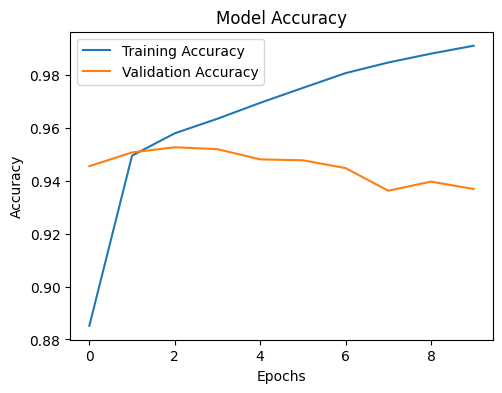

In [ ]:
 # Optionally, plot the accuracy and loss over epochs if you want
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

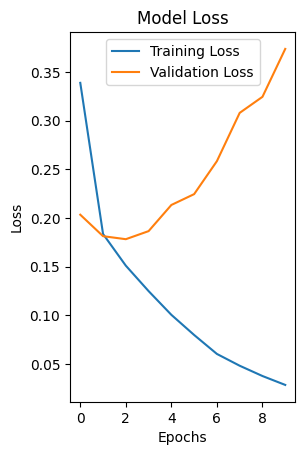

In [ ]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1) - 1  # Convert back to original labels -1, 0, 1
y_test_classes = np.argmax(y_test, axis=1) - 1
accuracy = accuracy_score(y_test_classes, y_pred_classes)
print(f"Test Accuracy: {accuracy:.4f}")


1528/1528 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step
Test Accuracy: 0.9373


In [ ]:
def predict_tweet(tweet):
    # Preprocess the tweet
    tweet = [tweet]  # Wrap in a list to match the input shape
    tweet_seq = tokenizer.texts_to_sequences(tweet)  # Tokenize the tweet
    tweet_padded = pad_sequences(tweet_seq, maxlen=max_len, padding='pre')  # Pad the sequence

    # Make a prediction
    prediction = model.predict(tweet_padded)  # Get the model prediction
    predicted_class = np.argmax(prediction, axis=1)  # Get the class index (0, 1, or 2)

    # Map class index to label
    labels = ['Negative', 'Neutral', 'Positive']
    return labels[predicted_class[0]]

# Test the model with a tweet
test_tweet = "I love this product! It's fantastic."  # Replace with any tweet you want to test
result = predict_tweet(test_tweet)
print(f'The tweet is classified as: {result}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
The tweet is classified as: Positive
